# Credit Card Customer Churn Analysis

## 1. Import Libraries

I first import the Python libraries needed for data handling, visualisation, and simple modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', 50)

project_root = Path.cwd()

if not (project_root / 'data').exists() and (project_root.parent / 'data').exists():
    project_root = project_root.parent

data_path = project_root / 'data' / 'credit_card_churn.csv'
output_dir = project_root / 'outputs'
output_dir.mkdir(exist_ok=True)

print('Project root:', project_root)
print('Data path:', data_path)

Project root: /content
Data path: /content/data/credit_card_churn.csv


## 2. Load the Dataset

The dataset is loaded from the `data` folder. I check the first few rows and the size of the dataset before cleaning.

In [2]:
df = pd.read_csv(data_path)

print('Rows and columns:', df.shape)
df.head()

Rows and columns: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3. Basic Data Checks

This section checks data types, missing values, duplicate rows, and the target variable.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [4]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(10)

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [5]:
duplicate_rows = df.duplicated().sum()
print('Number of duplicate rows:', duplicate_rows)

Number of duplicate rows: 0


In [6]:
target_counts = df['Attrition_Flag'].value_counts()
target_percent = df['Attrition_Flag'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_percent.round(2)
})

target_summary

,Count,Percentage
Attrition_Flag,,
Existing Customer,8500,83.93
Attrited Customer,1627,16.07


## 4. Data Cleaning

I remove `CLIENTNUM` because it is only a customer ID. I also remove the two pre-generated Naive Bayes classifier columns. These columns are not suitable for this project because they already contain prediction-related information from another model.

Then I create a binary churn variable:

- `1` = attrited customer
- `0` = existing customer

In [7]:
columns_to_drop = ['CLIENTNUM']

naive_bayes_columns = [col for col in df.columns if col.startswith('Naive_Bayes_Classifier')]
columns_to_drop = columns_to_drop + naive_bayes_columns

df_clean = df.drop(columns=columns_to_drop).copy()

df_clean['Churn'] = df_clean['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

df_clean = df_clean.drop(columns=['Attrition_Flag'])

print('Dropped columns:')
for col in columns_to_drop:
    print('-', col)

print('\nCleaned data shape:', df_clean.shape)
df_clean.head()

Dropped columns:
- CLIENTNUM
- Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1
- Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2

Cleaned data shape: (10127, 20)


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [8]:
cleaned_data_path = output_dir / 'cleaned_credit_card_churn.csv'
df_clean.to_csv(cleaned_data_path, index=False)

print('Cleaned dataset saved to:', cleaned_data_path)

Cleaned dataset saved to: /content/outputs/cleaned_credit_card_churn.csv


## 5. Descriptive Statistics

This section gives a simple overview of the cleaned dataset. It helps to understand the size and basic pattern of customer churn.

In [ ]:
df_clean.describe().round(2)

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27,0.16
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28,0.37
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02,0.00
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18,0.00
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50,0.00
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00,1.00


In [9]:
churn_count = df_clean['Churn'].value_counts().sort_index()
churn_percent = df_clean['Churn'].value_counts(normalize=True).sort_index() * 100

churn_summary = pd.DataFrame({
    'Churn_Status': ['Existing Customer', 'Attrited Customer'],
    'Count': churn_count.values,
    'Percentage': churn_percent.round(2).values
})

churn_summary

,Churn_Status,Count,Percentage
0,Existing Customer,8500,83.93
1,Attrited Customer,1627,16.07


**Short interpretation**

Most customers are existing customers. The churn group is smaller, so the data is imbalanced. This means model accuracy alone is not enough. Recall and F1-score are also useful when checking the model.

## 6. Exploratory Data Analysis

This section uses charts to compare churn patterns across customer groups and account behaviour variables.

### 6.1 Overall Churn Distribution

<Figure size 700x500 with 0 Axes>

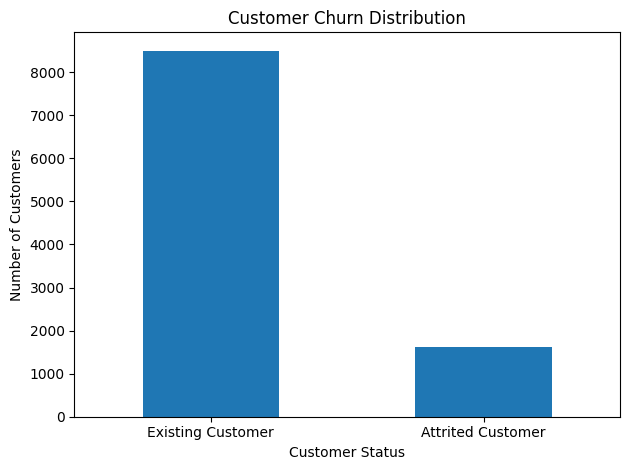

In [10]:
plt.figure(figsize=(7, 5))
churn_summary.plot(x='Churn_Status', y='Count', kind='bar', legend=False)
plt.title('Customer Churn Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / 'churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Churn Rate by Income Category

This chart checks whether some income groups have higher churn rates.

In [11]:
income_churn = df_clean.groupby('Income_Category')['Churn'].mean().sort_values(ascending=False).reset_index()
income_churn['Churn_Rate_Percentage'] = (income_churn['Churn'] * 100).round(2)

income_churn

,Income_Category,Churn,Churn_Rate_Percentage
0,$120K +,0.173315,17.33
1,Less than $40K,0.171862,17.19
2,Unknown,0.168165,16.82
3,$80K - $120K,0.157655,15.77
4,$40K - $60K,0.151397,15.14
5,$60K - $80K,0.134807,13.48


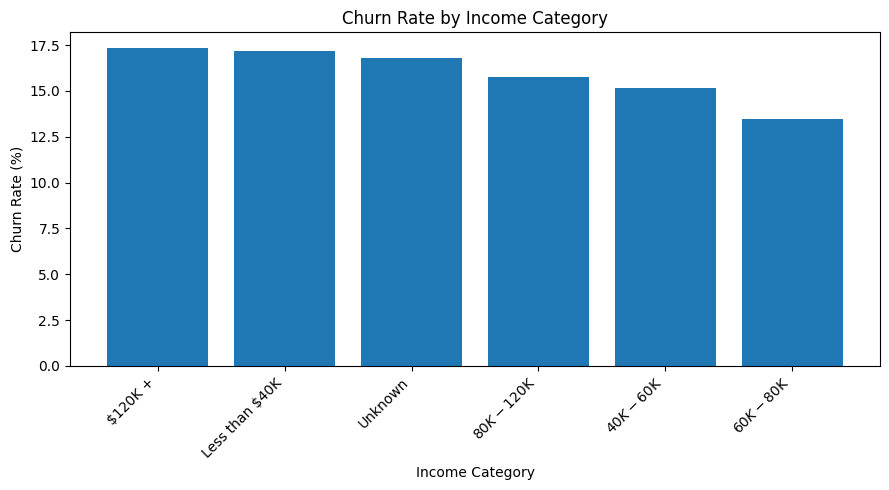

In [12]:
plt.figure(figsize=(9, 5))
plt.bar(income_churn['Income_Category'], income_churn['Churn_Rate_Percentage'])
plt.title('Churn Rate by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_dir / 'churn_by_income_category.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Churn Rate by Card Category

This chart checks whether churn differs by credit card product type.

In [13]:
card_churn = df_clean.groupby('Card_Category')['Churn'].mean().sort_values(ascending=False).reset_index()
card_churn['Churn_Rate_Percentage'] = (card_churn['Churn'] * 100).round(2)
card_churn

,Card_Category,Churn,Churn_Rate_Percentage
0,Platinum,0.250000,25.00
1,Gold,0.181034,18.10
2,Blue,0.160979,16.10
3,Silver,0.147748,14.77


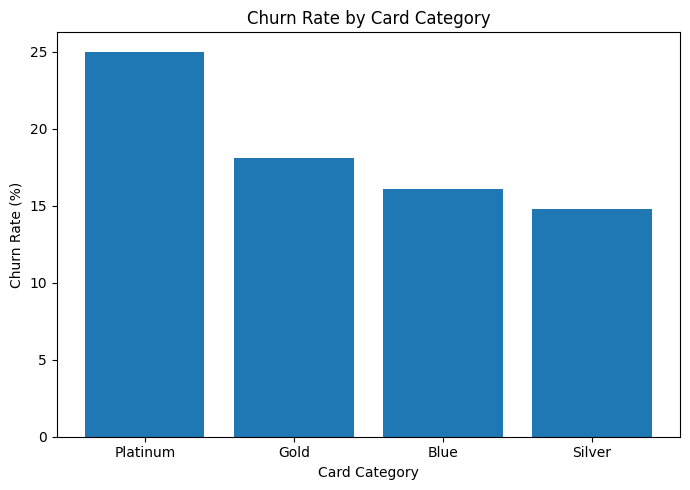

In [14]:
plt.figure(figsize=(7, 5))
plt.bar(card_churn['Card_Category'], card_churn['Churn_Rate_Percentage'])
plt.title('Churn Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(output_dir / 'churn_by_card_category.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.4 Churn Rate by Months Inactive

This chart is important for a retention team because inactivity can be an early warning sign.

In [15]:
inactive_churn = df_clean.groupby('Months_Inactive_12_mon')['Churn'].mean().reset_index()
inactive_churn['Churn_Rate_Percentage'] = (inactive_churn['Churn'] * 100).round(2)
inactive_churn

,Months_Inactive_12_mon,Churn,Churn_Rate_Percentage
0,0,0.517241,51.72
1,1,0.044783,4.48
2,2,0.153870,15.39
3,3,0.214769,21.48
4,4,0.298851,29.89
5,5,0.179775,17.98
6,6,0.153226,15.32


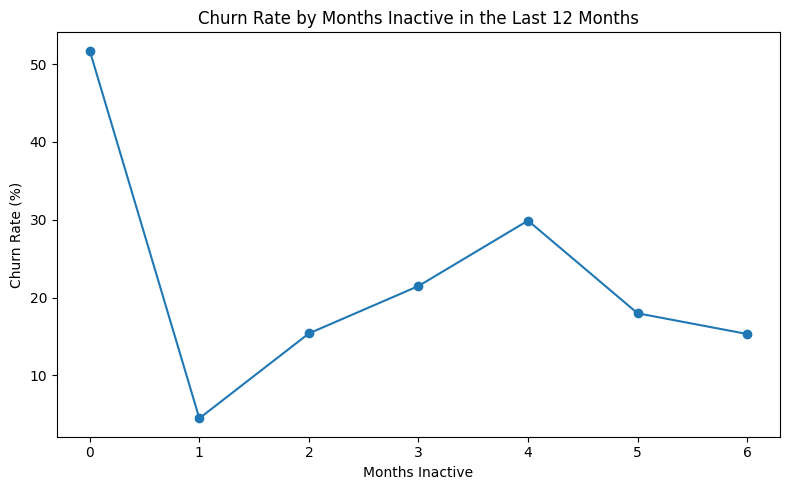

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(inactive_churn['Months_Inactive_12_mon'], inactive_churn['Churn_Rate_Percentage'], marker='o')
plt.title('Churn Rate by Months Inactive in the Last 12 Months')
plt.xlabel('Months Inactive')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(output_dir / 'churn_by_inactive_months.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.5 Churn Rate by Customer Contact Count

A high number of contacts may suggest service issues or dissatisfaction. It is not always negative, but it is useful to check.

In [17]:
contacts_churn = df_clean.groupby('Contacts_Count_12_mon')['Churn'].mean().reset_index()
contacts_churn['Churn_Rate_Percentage'] = (contacts_churn['Churn'] * 100).round(2)

contacts_churn

,Contacts_Count_12_mon,Churn,Churn_Rate_Percentage
0,0,0.017544,1.75
1,1,0.072048,7.20
2,2,0.124884,12.49
3,3,0.201479,20.15
4,4,0.226293,22.63
5,5,0.335227,33.52
6,6,1.000000,100.00


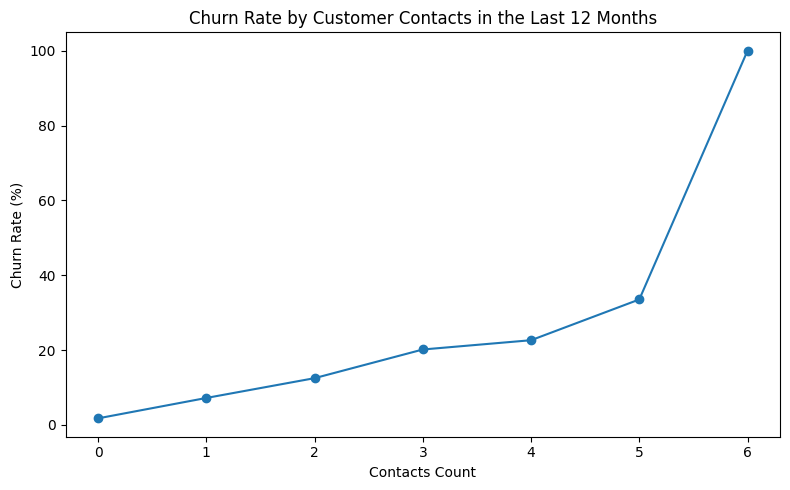

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(contacts_churn['Contacts_Count_12_mon'], contacts_churn['Churn_Rate_Percentage'], marker='o')
plt.title('Churn Rate by Customer Contacts in the Last 12 Months')
plt.xlabel('Contacts Count')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(output_dir / 'churn_by_contacts_count.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.6 Transaction Count by Churn Status

This boxplot compares transaction count between existing and attrited customers.

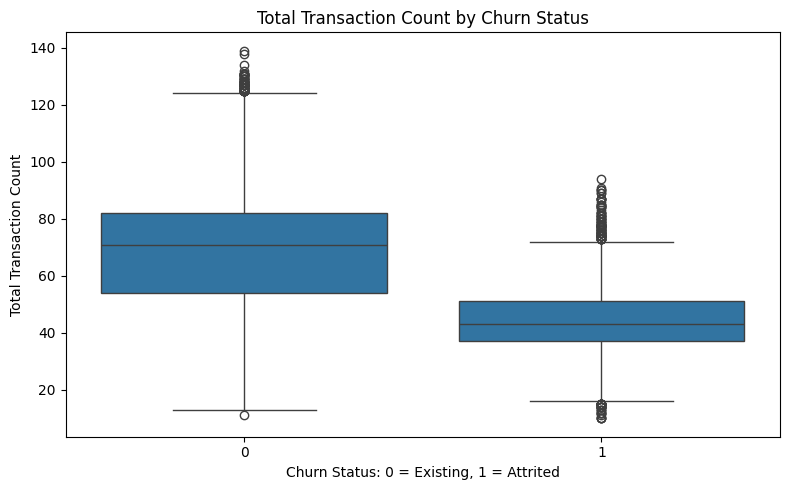

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Churn', y='Total_Trans_Ct')
plt.title('Total Transaction Count by Churn Status')
plt.xlabel('Churn Status: 0 = Existing, 1 = Attrited')
plt.ylabel('Total Transaction Count')
plt.tight_layout()
plt.savefig(output_dir / 'transaction_count_by_churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
transaction_summary = df_clean.groupby('Churn')[['Total_Trans_Ct', 'Total_Trans_Amt', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon']].mean().round(2)
transaction_summary

,Total_Trans_Ct,Total_Trans_Amt,Months_Inactive_12_mon,Contacts_Count_12_mon
Churn,,,,
0,68.67,4654.66,2.27,2.36
1,44.93,3095.03,2.69,2.97


### 6.7 Correlation Heatmap

The heatmap is used to check relationships between numeric variables. This is a simple way to find variables that move together.

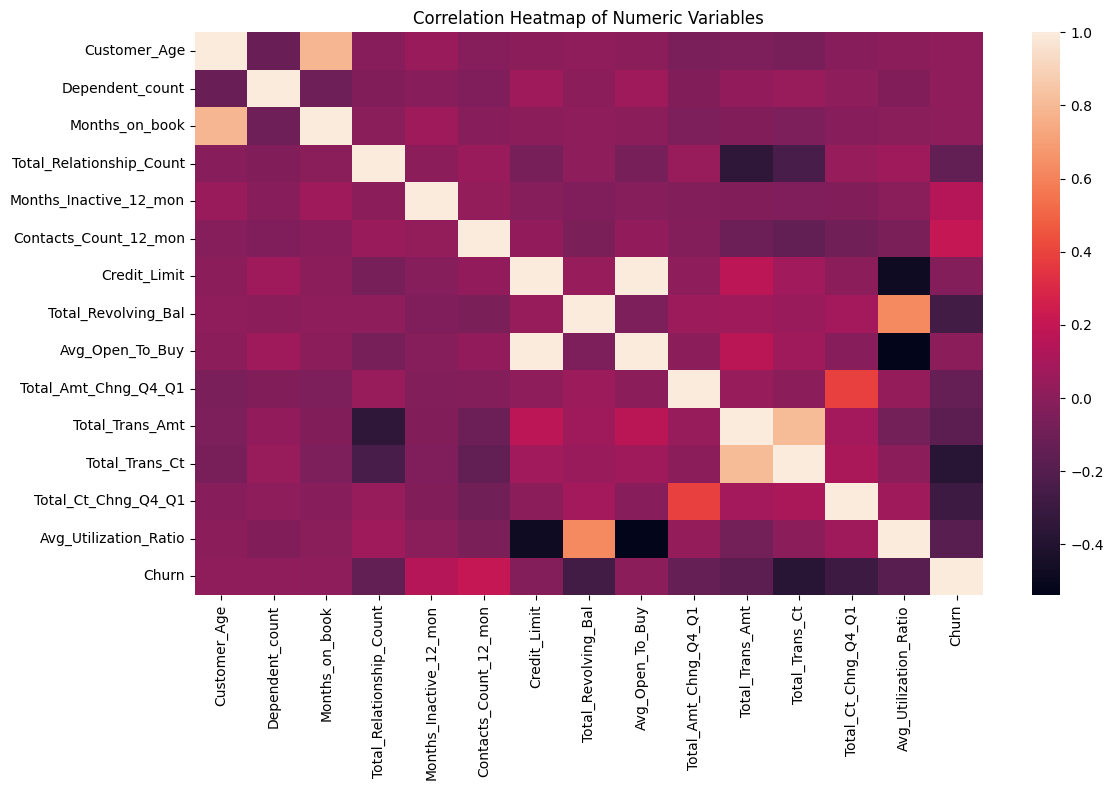

In [21]:
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[numeric_columns].corr(), annot=False)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.savefig(output_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Simple Classification Models

I use two simple models:

1. Logistic Regression
2. Decision Tree

The models are not used as final banking systems. They are used as simple screening tools for learning and for basic business insight.

In [22]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

categorical_columns = X.select_dtypes(include=['object']).columns
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

print('Categorical columns:')
print(list(categorical_columns))

print('\nNumeric columns:')
print(list(numeric_columns))

Categorical columns:
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

Numeric columns:
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Training churn rate:', round(y_train.mean() * 100, 2), '%')
print('Test churn rate:', round(y_test.mean() * 100, 2), '%')

Training rows: 8101
Test rows: 2026
Training churn rate: 16.07 %
Test churn rate: 16.04 %


In [24]:
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', encoder, categorical_columns)
    ]
)

### 7.1 Logistic Regression

I use `class_weight='balanced'` because the churn group is smaller than the existing customer group.

In [25]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, logistic_pred))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1701
           1       0.53      0.82      0.64       325

    accuracy                           0.85      2026
   macro avg       0.75      0.84      0.78      2026
weighted avg       0.89      0.85      0.87      2026



In [26]:
logistic_confusion = pd.DataFrame(
    confusion_matrix(y_test, logistic_pred),
    index=['Actual Existing', 'Actual Attrited'],
    columns=['Predicted Existing', 'Predicted Attrited']
)

logistic_confusion

,Predicted Existing,Predicted Attrited
Actual Existing,1466,235
Actual Attrited,59,266


### 7.2 Decision Tree

The decision tree is included because it gives a more rule-based view of churn risk. I keep the tree shallow to reduce overfitting.

In [27]:
tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.91      1701
           1       0.55      0.90      0.68       325

    accuracy                           0.87      2026
   macro avg       0.76      0.88      0.80      2026
weighted avg       0.91      0.87      0.88      2026



In [28]:
tree_confusion = pd.DataFrame(
    confusion_matrix(y_test, tree_pred),
    index=['Actual Existing', 'Actual Attrited'],
    columns=['Predicted Existing', 'Predicted Attrited']
)

tree_confusion

,Predicted Existing,Predicted Attrited
Actual Existing,1459,242
Actual Attrited,31,294


## 8. Model Comparison

I compare the models using several metrics. Accuracy is included, but it should not be the only measure because the target variable is imbalanced.

In [30]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred)
    ],
    'Precision': [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, tree_pred)
    ],
    'Recall': [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, tree_pred)
    ],
    'F1_Score': [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, tree_pred)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, tree_prob)
    ]
})

model_results = model_results.round(3)

model_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.855,0.531,0.818,0.644,0.921
1,Decision Tree,0.865,0.549,0.905,0.683,0.941


## 9. Decision Tree Feature Importance

This section checks which variables are most important in the simple decision tree model. This helps connect the model back to business interpretation.

In [31]:
feature_names = tree_model.named_steps['preprocessor'].get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_model.named_steps['classifier'].feature_importances_
})

feature_importance = feature_importance.sort_values('Importance', ascending=False).head(10)

feature_importance

,Feature,Importance
11,num__Total_Trans_Ct,0.593790
10,num__Total_Trans_Amt,0.160649
7,num__Total_Revolving_Bal,0.125119
3,num__Total_Relationship_Count,0.076614
12,num__Total_Ct_Chng_Q4_Q1,0.023999
6,num__Credit_Limit,0.009751
4,num__Months_Inactive_12_mon,0.004293
9,num__Total_Amt_Chng_Q4_Q1,0.003594
35,cat__Card_Category_Platinum,0.002192
1,num__Dependent_count,0.000000


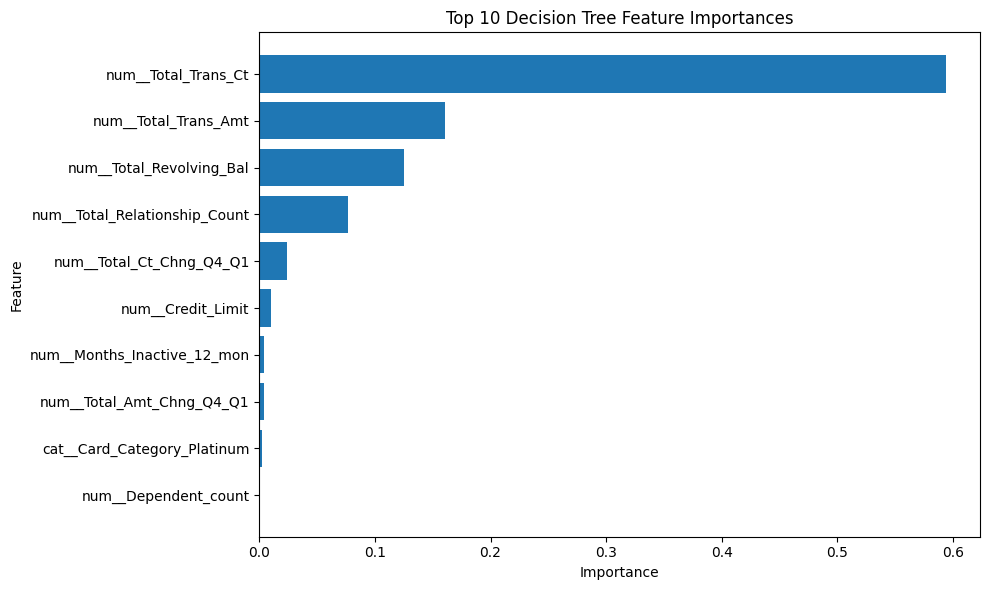

In [32]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Top 10 Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / 'decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Main Business Insights

The analysis gives several practical insights for a bank retention team.

**Insight 1: Inactive customers need early attention.**  
Customers with more inactive months show higher churn risk. The bank could create a monitoring list for customers with several inactive months.

**Insight 2: Low transaction activity is a useful warning sign.**  
Attrited customers tend to have lower transaction counts and lower transaction amounts. The bank could send personalised usage offers before the customer becomes fully inactive.

**Insight 3: Frequent contacts may indicate dissatisfaction.**  
Customers who contact the bank many times may have unresolved service issues. These customers could be followed up by a service recovery team.

**Insight 4: Simple models can support screening.**  
The logistic regression and decision tree models can help flag higher-risk customers. However, the model should support human judgement rather than replace it.

## 11. Limitations and Improvements

This project has some limitations.

First, the data is observational. It can show relationships, but it cannot prove the causes of churn. Second, the dataset does not include customer satisfaction, complaint text, competitor offers, or service quality records. These missing variables may be important. Third, the models are simple and only used for a student-level data product.

Future improvements could include more recent transaction history, complaint records, customer survey data, and a more careful model validation process.